# **Logistic Regression from Scratch**

## 0.ライブラリのインポートとデータの生成

特徴量（10段階評価）

x1 : 病気の要因1（例：血圧）  
x2 : 病気の要因2（例：コレステロール）

目的変数

y : 病気の有無  
0 = 健康  
1 = 病気

ロジスティック回帰モデルを用いて、人工的にデータを生成する。

z = b0 + b1x1 + b2x2

p = 1 / (1 + e^(-z))

p > 0.5 => 病気  
p ≤ 0.5 => 健康

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import random

data_number = 20
true_b0 = -10
true_b1 = 1
true_b2 = 1

data = []

for _ in range(data_number):
    x1 = np.random.uniform(0,10)
    x2 = np.random.uniform(0,10)
    z = true_b0 + true_b1*x1 + true_b2*x2
    p = 1 / (1 + np.exp(-z))

    if p > 0.5:
        y = 1
    else:
        y = 0

    data.append([x1, x2, y])

input_data = np.array(data)

## 1.アルゴリズム

### 1.1.リスクの相乗モデルとシグモイド関数の導出

リスクの相乗モデルからシグモイド関数を導出する。

病気になる確率 => p 健康である確率 => 1 - p

odds = p / (1 - p)　※1

リスクの相乗モデルよりリスクが乗算的に増加すると仮定する。

odds = exp(b0 + b1x1 + b2x2)　※2

※1、※2より

p / (1 - p) = exp(b0 + b1x1 + b2x2)

z = b0 + b1x1 + b2x2 として

p = 1 / (1 + exp(-z))

### 1.2.勾配降下法

b0、b1、b2 を勾配降下法を用いて最適化する。

z = b0 + b1x1 + b2x2

s = 1 / (1 + e^(-z))

各パラメータの勾配

db0 = Σ (y - s)

db1 = Σ (y - s)x1

db2 = Σ (y - s)x2

In [50]:
epochs = 500
alpha = 0.005

b0 = random.uniform(0.1, 5.0)
b1 = random.uniform(0.1, 5.0)
b2 = random.uniform(0.1, 5.0)

for j in range(epochs):

  db0 = 0
  db1 = 0
  db2 = 0

  for i in range(data_number):
    x1 = input_data[i, 0]
    x2 = input_data[i, 1]
    y = input_data[i, 2]
    z = b0 + b1*x1 + b2*x2
    s = 1 / (1 + np.exp(-z))

    if y == 1:
      db0 = db0 + (1 - s)
      db1 = db1 + (1 - s)*x1
      db2 = db2 + (1 - s)*x2
    else:
      db0 = db0 + (-s)
      db1 = db1 + (-s)*x1
      db2 = db2 + (-s)*x2

  b0 = b0 + alpha*db0
  b1 = b1 + alpha*db1
  b2 = b2 + alpha*db2

## 2.モデルの可視化

2つの特徴量 x1、x2 を用いて、データを2次元空間にプロットする。

赤 => 病気  
青 => 健康

決定境界(decision boundary)

b0 + b1x1 + b2x2 = 0

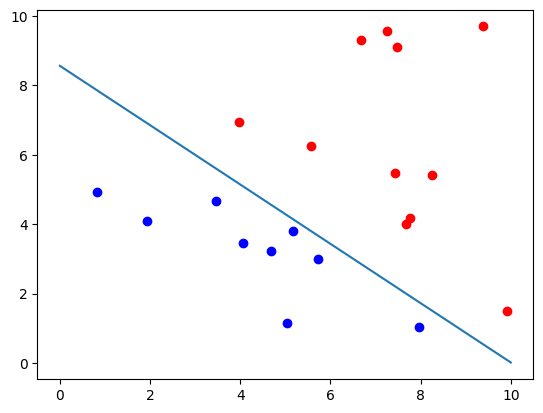

In [51]:
x1_line = np.linspace(0, 10, 100)
x2_line = - (b0 / b2) - (b1 / b2)*x1_line
plt.plot(x1_line, x2_line)

for n in range(data_number):
  x1 = input_data[n, 0]
  x2 = input_data[n, 1]
  y = input_data[n, 2]

  if y == 1:
    plt.scatter(x1, x2, color='red')
  else:
    plt.scatter(x1, x2, color='blue')

plt.show()

## 3.検証

### 3.1.直線の比較

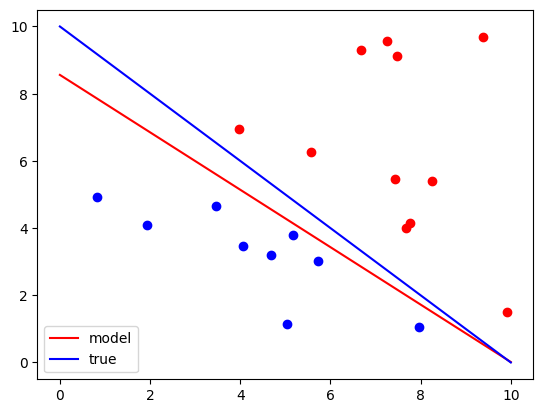

In [53]:
x1_true_line = np.linspace(0, 10, 100)
x2_true_line = - (true_b0 / true_b2) - (true_b1 / true_b2)*x1_true_line
plt.plot(x1_line, x2_line, label="model", color='red')
plt.plot(x1_true_line, x2_true_line, label="true", color="blue")

for n in range(data_number):
  x1 = input_data[n, 0]
  x2 = input_data[n, 1]
  y = input_data[n, 2]

  if y == 1:
    plt.scatter(x1, x2, color='red')
  else:
    plt.scatter(x1, x2, color='blue')

plt.legend()
plt.show()

### 3.2.パラメータの比較

真のデータ

b0 = -10  
b1 = 1  
b2 = 1

学習の結果  
b0 = -3.77  
b1 = 0.37  
b2 = 0.44

In [52]:
print(b0, b1, b2)

-3.7689600284484 0.37628624723753 0.4403450130341704
